# StormEngine DPC Station Data Quality & Analysis

| Column | Description |
|---|---|
| `station_id` | Unique station identifier, namespaced by source |
| `station_name` | Human-readable station name |
| `lat`, `lon` | Station coordinates |
| `gestore` | Data provider / managing authority |
| `source` | Originating dataset (`DPC`, `ARPAE`, `ARPAV`, `ADRIATIC`) |
| `<VAR>_value` | Latest value of canonical variable `VAR` (`PREC`, `TARIA2M`, `PRESS`, `VV`, `UMID2M`) |
| `<VAR>_dt` | UTC timestamp of that latest value |

## 0. Imports and Configuration

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'legend.frameon': False,
})

# ── Input file ──────────────────────────────────────────────────────────
# Same folder as this notebook (DataAggregation\DPC)
INPUT_FILE = Path('DPC_stations_aggregated.csv')

# Canonical variables present in the aggregated wide file
CANON_VARS = ['PREC', 'TARIA2M', 'PRESS', 'VV', 'UMID2M']

# ── Domain ───────────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = 39.0, 46.5
LON_MIN, LON_MAX = 12.0, 20.0

# ── Physical plausibility bounds per canonical variable ────────────────
PHYS_BOUNDS = {
    'TARIA2M' : (-20.0,  50.0),   # °C
    'PRESS'   : (950.0, 1060.0),  # hPa
    'VV'      : (  0.0,  60.0),   # m/s
    'PREC'    : (  0.0, 200.0),   # mm (instantaneous / cumulated reading)
    'UMID2M'  : (  0.0, 100.0),   # %
}

VAR_COLORS = {
    'TARIA2M': '#e6550d',
    'PRESS'  : '#3182bd',
    'VV'     : '#31a354',
    'PREC'   : '#756bb1',
    'UMID2M' : '#c994c7',
}

print('Configuration loaded.')

Configuration loaded.


# STEP 1 Sensor Inventory & Data Dictionary

Documents which canonical variables are available at each station, with
coordinates and provider. This constitutes the formal data dictionary for
the aggregated snapshot.

## 1.1 Load the Aggregated CSV

In [16]:
def load_aggregated(path):
    """Load the wide-format aggregated station CSV and parse all *_dt columns."""
    if not path.exists():
        raise FileNotFoundError(f'{path} not found — check INPUT_FILE.')
    df = pd.read_csv(path)
    for var in CANON_VARS:
        dtcol = f'{var}_dt'
        if dtcol in df.columns:
            df[dtcol] = pd.to_datetime(df[dtcol], errors='coerce', utc=True)
    return df

INPUT_FILE = Path('DPC_stations_aggregated.csv')
dpc = load_aggregated(INPUT_FILE)

available_vars = [v for v in CANON_VARS if f'{v}_value' in dpc.columns]

dt_series = [dpc[f'{v}_dt'] for v in available_vars if f'{v}_dt' in dpc.columns]
if dt_series:
    all_dt = pd.concat(dt_series)
    print(f'Timestamp range   : {all_dt.min()} → {all_dt.max()}')
else:
    print('Timestamp range   : no _dt columns found in file')
    print('Columns found     :', [c for c in dpc.columns if '_dt' in c])

print(f'Total stations   : {len(dpc)}')
print(f'Unique station_id: {dpc["station_id"].nunique()}')
print(f'Canonical vars    : {available_vars}')
print(f'Gestori           : {sorted(dpc["gestore"].dropna().unique())}')
print(f'Sources           : {sorted(dpc["source"].dropna().unique())}')

Timestamp range   : 2026-06-21 10:00:00+00:00 → 2026-06-21 16:10:00+00:00
Total stations   : 752
Unique station_id: 752
Canonical vars    : ['PREC', 'TARIA2M', 'PRESS', 'VV', 'UMID2M']
Gestori           : ['ARPAE', 'ARPAV', 'DPC', 'MeteoHub_dpcn-marche']
Sources           : ['ADRIATIC', 'ARPAE', 'ARPAV', 'DPC']


## 1.2 Missing values per variable

Checking how many stations have no reported value at all for each canonical variable.

In [17]:
print('='*55)
print('  MISSING VALUES CHECK')
print('='*55)

for var in available_vars:
    vcol = f'{var}_value'
    n_missing = dpc[vcol].isna().sum()
    print(f'  {var:8s}: {n_missing:4d} missing (out of {len(dpc)})')

  MISSING VALUES CHECK
  PREC    :   37 missing (out of 752)
  TARIA2M :  135 missing (out of 752)
  PRESS   :  709 missing (out of 752)
  VV      :  610 missing (out of 752)
  UMID2M  :  603 missing (out of 752)


## 1.3 Zero readings per variable

Checking how many stations report an exact 0 value

In [18]:
print('='*55)
print('  ZERO READINGS CHECK')
print('='*55)

for var in available_vars:
    vcol = f'{var}_value'
    n_zero = (dpc[vcol] == 0).sum()
    print(f'  {var:8s}: {n_zero:4d} zero readings (out of {len(dpc)})')

  ZERO READINGS CHECK
  PREC    :  648 zero readings (out of 752)
  TARIA2M :    0 zero readings (out of 752)
  PRESS   :    0 zero readings (out of 752)
  VV      :    2 zero readings (out of 752)
  UMID2M  :    0 zero readings (out of 752)


## 1.4 Station ID length

Checking how long the `station_id` values are: they are unique, but some are long and not easily readable.

In [19]:
print('='*55)
print('  STATION ID LENGTH CHECK')
print('='*55)

avg_id_len = dpc['station_id'].str.len().mean()
max_id_len = dpc['station_id'].str.len().max()
print(f'  Average length: {avg_id_len:.1f} chars')
print(f'  Max length    : {max_id_len} chars')
print('  Example long ID:', dpc.loc[dpc['station_id'].str.len() == max_id_len, 'station_id'].iloc[0])

  STATION ID LENGTH CHECK
  Average length: 16.6 chars
  Max length    : 49 chars
  Example long ID: ADRIATIC::MH_dpcn-marche_Piscina_Acquasanta_Terme


In [20]:
# ---- 1.4b Station ID renaming ----
# ADRIATIC::... -> METEOHUB::1, 2, 3... (alphabetical order)
adriatic_ids = sorted(dpc.loc[dpc['station_id'].str.startswith('ADRIATIC'), 'station_id'].unique())
adriatic_map = {old: f'METEOHUB::{i+1}' for i, old in enumerate(adriatic_ids)}

# ARPAE::STA_... -> ARPAE::1, 2, 3... (alphabetical order)
arpae_ids = sorted(dpc.loc[dpc['station_id'].str.startswith('ARPAE'), 'station_id'].unique())
arpae_map = {old: f'ARPAE::{i+1}' for i, old in enumerate(arpae_ids)}

# Merge both maps and apply
rename_map = {**adriatic_map, **arpae_map}
dpc['station_id'] = dpc['station_id'].replace(rename_map)

print(f'  Renamed {len(adriatic_map)} ADRIATIC -> METEOHUB::N')
print(f'  Renamed {len(arpae_map)} ARPAE::STA_... -> ARPAE::N')
print(f'  Sample METEOHUB:', list(adriatic_map.values())[:3])
print(f'  Sample ARPAE   :', list(arpae_map.values())[:3])

  Renamed 122 ADRIATIC -> METEOHUB::N
  Renamed 158 ARPAE::STA_... -> ARPAE::N
  Sample METEOHUB: ['METEOHUB::1', 'METEOHUB::2', 'METEOHUB::3']
  Sample ARPAE   : ['ARPAE::1', 'ARPAE::2', 'ARPAE::3']


## 1.5 Data Dictionary: Sensor Inventory Table

One row per (station, variable) pair actually populated in the aggregated
file: this keeps the dictionary in the same shape used in the original pipeline.

In [21]:
rows = []
for var in available_vars:
    vcol, dcol = f'{var}_value', f'{var}_dt'
    sub = dpc[['station_id', 'station_name', 'lat', 'lon', 'gestore', 'source', vcol, dcol]].copy()
    sub = sub.rename(columns={vcol: 'value', dcol: 'dt'})
    sub = sub[sub['value'].notna()]
    sub['variable'] = var
    rows.append(sub)

inventory = pd.concat(rows, ignore_index=True)
inventory = inventory[['station_id', 'station_name', 'variable', 'value', 'dt',
                       'lat', 'lon', 'gestore', 'source']]

print(f'Data dictionary: {len(inventory)} populated (station, variable) pairs')
print()
print('Active variables — station count:')
print(inventory.groupby('variable')['station_id'].nunique().rename('n_stations').to_string())
print()
print('Sample rows:')
inventory.head(8)

Data dictionary: 1666 populated (station, variable) pairs

Active variables — station count:
variable
PREC       715
PRESS       43
TARIA2M    617
UMID2M     149
VV         142

Sample rows:


,station_id,station_name,variable,value,dt,lat,lon,gestore,source
0,METEOHUB::1,Acqualagna,PREC,0.0,2026-06-21 16:00:00+00:00,43.62819,12.68448,MeteoHub_dpcn-marche,ADRIATIC
1,METEOHUB::2,Agugliano,PREC,0.0,2026-06-21 16:00:00+00:00,43.54330,13.38060,MeteoHub_dpcn-marche,ADRIATIC
2,METEOHUB::3,Amandola,PREC,0.0,2026-06-21 16:00:00+00:00,42.97638,13.35133,MeteoHub_dpcn-marche,ADRIATIC
3,METEOHUB::4,Ancona Regione,PREC,0.0,2026-06-21 16:00:00+00:00,43.61030,13.50830,MeteoHub_dpcn-marche,ADRIATIC
4,METEOHUB::5,Ancona Torrette,PREC,0.0,2026-06-21 16:00:00+00:00,43.61095,13.44980,MeteoHub_dpcn-marche,ADRIATIC
5,METEOHUB::6,Appignano,PREC,0.0,2026-06-21 16:00:00+00:00,43.36420,13.34310,MeteoHub_dpcn-marche,ADRIATIC
6,METEOHUB::7,Arcevia,PREC,0.0,2026-06-21 16:00:00+00:00,43.49750,12.93670,MeteoHub_dpcn-marche,ADRIATIC
7,METEOHUB::8,Arquata del Tronto,PREC,0.0,2026-06-21 16:00:00+00:00,42.77782,13.29545,MeteoHub_dpcn-marche,ADRIATIC


## 1.6 Sensor Availability per Station


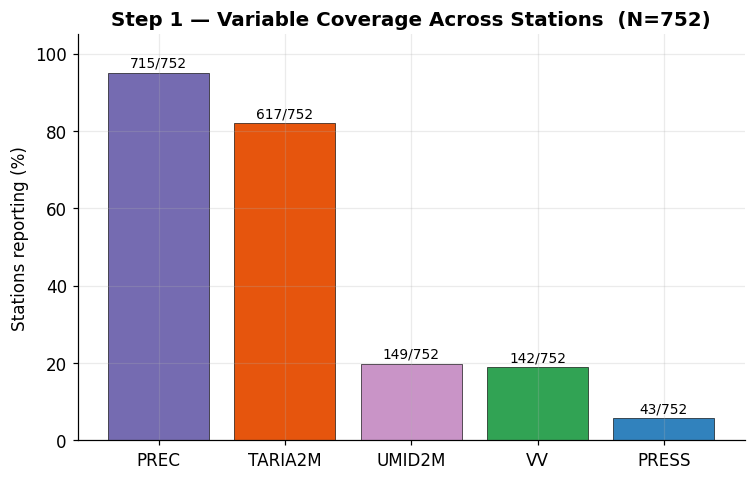

,variable,n_stations,pct_stations
0,PREC,715,95.079787
1,TARIA2M,617,82.047872
4,UMID2M,149,19.813830
3,VV,142,18.882979
2,PRESS,43,5.718085


In [22]:
coverage = pd.DataFrame({
    'variable': available_vars,
    'n_stations': [dpc[f'{v}_value'].notna().sum() for v in available_vars],
})
coverage['pct_stations'] = 100 * coverage['n_stations'] / len(dpc)
coverage = coverage.sort_values('n_stations', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(coverage['variable'], coverage['pct_stations'],
               color=[VAR_COLORS.get(v, 'steelblue') for v in coverage['variable']],
               edgecolor='black', linewidth=0.4)
for b, n, pct in zip(bars, coverage['n_stations'], coverage['pct_stations']):
    ax.text(b.get_x()+b.get_width()/2, pct+1.5, f'{n}/{len(dpc)}',
            ha='center', fontsize=9)
ax.set(ylabel='Stations reporting (%)', ylim=(0, 105),
       title=f'Step 1 — Variable Coverage Across Stations  (N={len(dpc)})')
plt.tight_layout()
plt.savefig('s1_sensor_availability.png', bbox_inches='tight')
plt.show()

coverage

## 1.7 Station Map

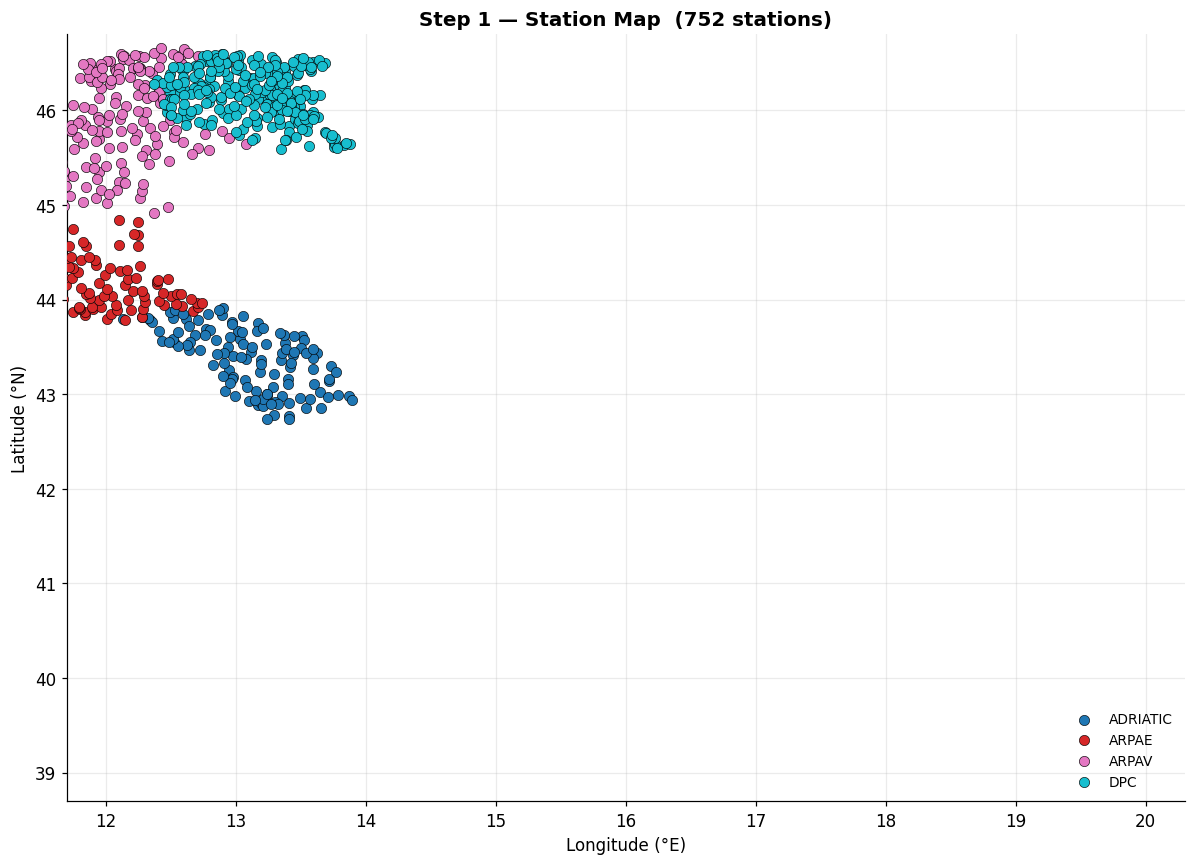

In [23]:
fig, ax = plt.subplots(figsize=(11, 8))
sources = dpc['source'].dropna().unique()
cmap_g = plt.cm.get_cmap('tab10', len(sources))
for idx, s in enumerate(sources):
    sub = dpc[dpc['source'] == s]
    ax.scatter(sub['lon'], sub['lat'], s=45, color=cmap_g(idx),
               edgecolors='black', linewidths=0.4, zorder=5, label=s)
ax.set(xlim=(LON_MIN-0.3, LON_MAX+0.3), ylim=(LAT_MIN-0.3, LAT_MAX+0.3),
       xlabel='Longitude (°E)', ylabel='Latitude (°N)',
       title=f'Step 1 — Station Map  ({len(dpc)} stations)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('s1_station_map.png', bbox_inches='tight')
plt.show()

# STEP 2 Real-Time Data Quality

**Physical plausibility range check**: flagging values that fall
outside realistic bounds for each variable. Flat-line and gap detection have
been removed, both require multiple timestamps per (station, variable),
which the aggregated snapshot does not contain by design.

## 2.1 Physical Range Check

  2.1 PHYSICAL RANGE CHECK
  PREC    :    0 out of  715 (0.00%)  bounds=[0.0,200.0]
  TARIA2M :    0 out of  617 (0.00%)  bounds=[-20.0,50.0]
  PRESS   :    9 out of   43 (20.93%)  bounds=[950.0,1060.0]
  Flagged stations:
  station_id         station_name  value
METEOHUB::56     Isola San Biagio  886.0
METEOHUB::65       Monte Bove Sud  821.0
METEOHUB::70          Monte Prata  838.0
METEOHUB::85 Pintura di Bolognola  876.0
METEOHUB::89    Pizzo Tre Vescovi  836.0
  VV      :    0 out of  142 (0.00%)  bounds=[0.0,60.0]
  UMID2M  :    0 out of  149 (0.00%)  bounds=[0.0,100.0]


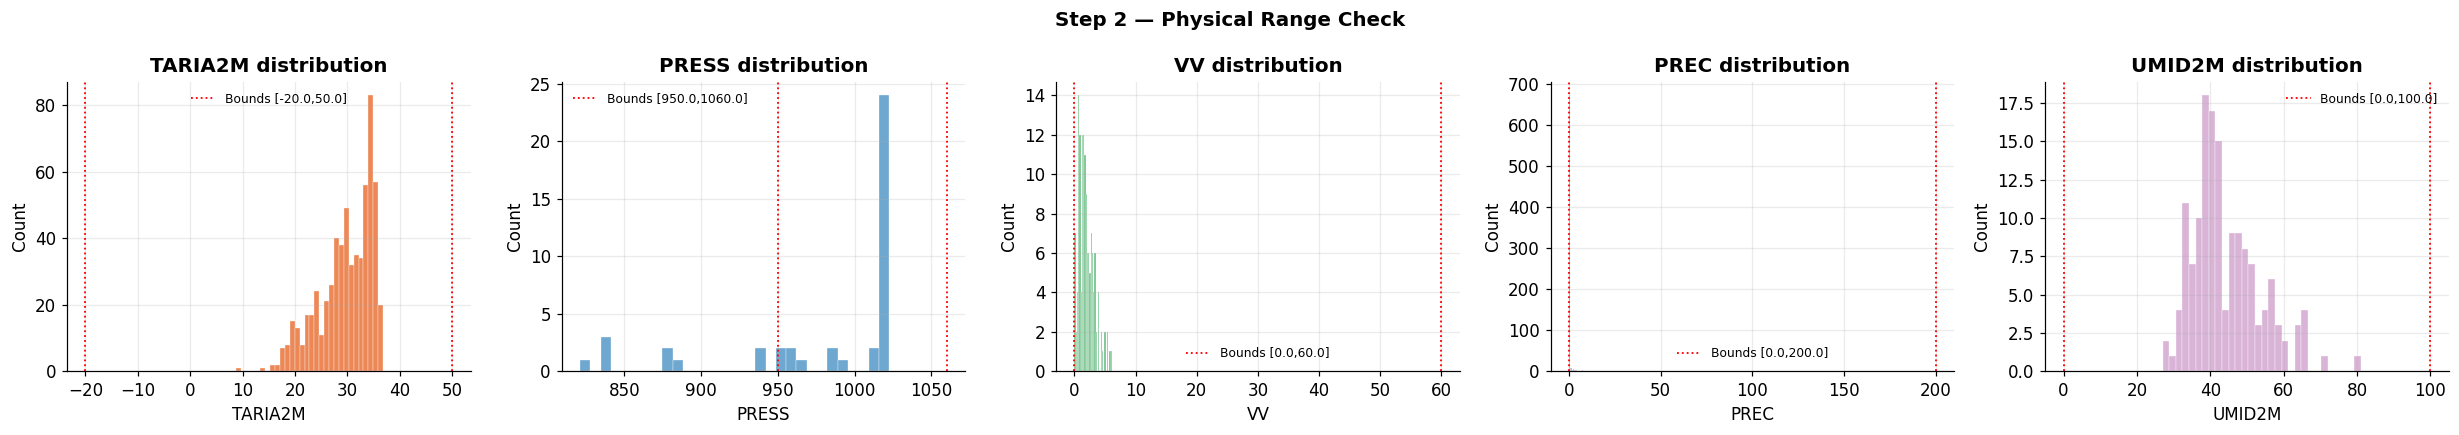

In [24]:
print('='*55)
print('  2.1 PHYSICAL RANGE CHECK')
print('='*55)

range_flags = []
dpc_flags = {}
for var in available_vars:
    if var not in PHYS_BOUNDS:
        continue
    lo, hi = PHYS_BOUNDS[var]
    vcol = f'{var}_value'
    sub = inventory[inventory['variable'] == var]
    if len(sub) == 0:
        continue
    bad = sub[(sub['value'] < lo) | (sub['value'] > hi)]
    pct = 100 * len(bad) / len(sub) if len(sub) > 0 else 0
    print(f'  {var:8s}: {len(bad):4d} out of {len(sub):4d} ({pct:.2f}%)  bounds=[{lo},{hi}]')
    range_flags.append({'variable': var, 'n_total': len(sub),
                        'n_bad': len(bad), 'pct_bad': pct})
    if len(bad) > 0:
        print('  Flagged stations:')
        print(bad[['station_id', 'station_name', 'value']].head(5).to_string(index=False))
    dpc_flags[var] = set(bad['station_id'])

range_df = pd.DataFrame(range_flags)

# Mark flagged rows directly on the wide table, one boolean column per variable
for var in available_vars:
    if var not in PHYS_BOUNDS:
        continue
    lo, hi = PHYS_BOUNDS[var]
    vcol = f'{var}_value'
    dpc[f'{var}_range_flag'] = (dpc[vcol] < lo) | (dpc[vcol] > hi)

# Visualise value distributions with bounds
codes = [c for c in PHYS_BOUNDS if c in available_vars]
fig, axes = plt.subplots(1, len(codes), figsize=(4.5*len(codes), 4))
if len(codes) == 1:
    axes = [axes]
for ax, c in zip(axes, codes):
    sub = dpc[f'{c}_value'].dropna()
    ax.hist(sub, bins=30, color=VAR_COLORS.get(c, 'steelblue'),
            alpha=0.7, edgecolor='white', linewidth=0.3)
    lo, hi = PHYS_BOUNDS[c]
    ax.axvline(lo, color='red', linestyle=':', linewidth=1.2)
    ax.axvline(hi, color='red', linestyle=':', linewidth=1.2,
               label=f'Bounds [{lo},{hi}]')
    ax.set(xlabel=c, ylabel='Count', title=f'{c} distribution')
    ax.legend(fontsize=8)
fig.suptitle('Step 2 — Physical Range Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('s2_range_check.png', bbox_inches='tight')
plt.show()

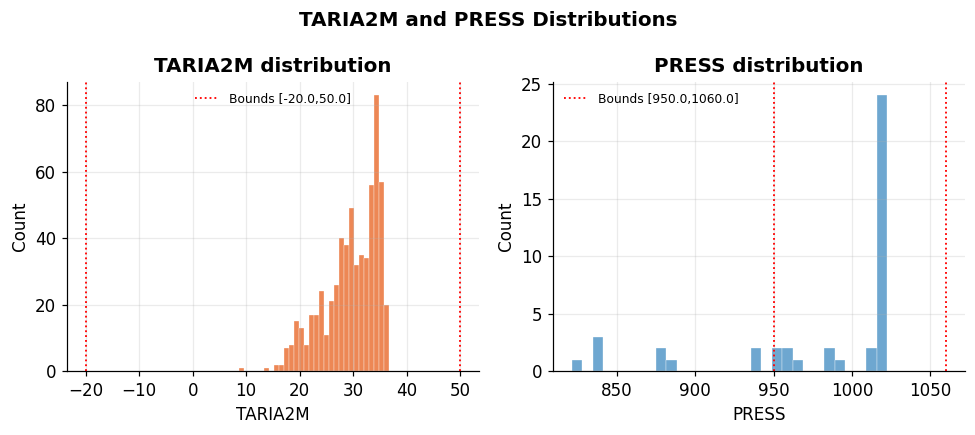

In [25]:
# Plot only TARIA2M and PRESS side by side
selected_codes = ['TARIA2M', 'PRESS']
codes = [c for c in selected_codes if c in available_vars and c in PHYS_BOUNDS]

fig, axes = plt.subplots(1, len(codes), figsize=(4.5*len(codes), 4))
if len(codes) == 1:
    axes = [axes]
for ax, c in zip(axes, codes):
    sub = dpc[f'{c}_value'].dropna()
    ax.hist(sub, bins=30, color=VAR_COLORS.get(c, 'steelblue'),
            alpha=0.7, edgecolor='white', linewidth=0.3)
    lo, hi = PHYS_BOUNDS[c]
    ax.axvline(lo, color='red', linestyle=':', linewidth=1.2)
    ax.axvline(hi, color='red', linestyle=':', linewidth=1.2,
               label=f'Bounds [{lo},{hi}]')
    ax.set(xlabel=c, ylabel='Count', title=f'{c} distribution')
    ax.legend(fontsize=8)

fig.suptitle('TARIA2M and PRESS Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('s2_taria2m_press.png', bbox_inches='tight')
plt.show()

# STEP 3 Relative Statistical Outliers & Coastal Proximity Weight

Two additional, independent diagnostics on top of the physical range check:

1. **Relative statistical outlier detection**, this flags stations whose 
   reading is anomalous *relative to the other stations
   reporting the same variable*, even when it sits inside the absolute
   physical bounds from Step 2.

2. **A coastal-proximity weight** in [0.1, 0.9], assigned per station,
   intended to express how close a station sits to the Adriatic coastline.


In [26]:
# ---- 3.1 Relative statistical outliers (MAD-based, per variable) ----

def mad_zscore(series):
    """Robust z-score using the Median Absolute Deviation.
    Returns NaN where the series has zero variability (MAD = 0)."""
    median = series.median()
    mad = (series - median).abs().median()
    if mad == 0 or pd.isna(mad):
        return pd.Series(np.nan, index=series.index)
    # 1.4826 scales MAD to be comparable to a normal-distribution std dev
    return 0.6745 * (series - median) / mad

OUTLIER_Z_THRESHOLD = 3.5  # common robust-outlier convention (Iglewicz & Hoaglin)

print('='*55)
print('  3.1 RELATIVE STATISTICAL OUTLIERS (per variable, MAD-based)')
print('='*55)

outlier_flags = []
for var in available_vars:
    vcol = f'{var}_value'
    valid = dpc[dpc[vcol].notna()]
    if len(valid) < 5:
        print(f'  {var:8s}: skipped (only {len(valid)} stations — too few for a robust estimate)')
        continue
    z = mad_zscore(valid[vcol])
    is_outlier = z.abs() > OUTLIER_Z_THRESHOLD
    n_out = is_outlier.sum()
    print(f'  {var:8s}: {n_out:4d} relative outliers out of {len(valid):4d} '
          f'({100*n_out/len(valid):.1f}%)  |z| > {OUTLIER_Z_THRESHOLD}')
    if n_out > 0:
        flagged = valid.loc[is_outlier, ['station_id', 'station_name', vcol]].copy()
        flagged['robust_z'] = z[is_outlier].round(2)
        print(flagged.sort_values('robust_z', key=abs, ascending=False).head(5).to_string(index=False))
    dpc.loc[valid.index, f'{var}_robust_z'] = z
    dpc.loc[valid.index, f'{var}_outlier_flag'] = is_outlier
    outlier_flags.append(var)

# Combine into one summary boolean per station
flag_cols_outlier = [f'{v}_outlier_flag' for v in outlier_flags if f'{v}_outlier_flag' in dpc.columns]
dpc['any_outlier_flag'] = dpc[flag_cols_outlier].any(axis=1, skipna=True) if flag_cols_outlier else False

print(f'\n  Stations with at least one relative outlier: {dpc["any_outlier_flag"].sum()}')

  3.1 RELATIVE STATISTICAL OUTLIERS (per variable, MAD-based)
  PREC    :    0 relative outliers out of  715 (0.0%)  |z| > 3.5
  TARIA2M :    1 relative outliers out of  617 (0.2%)  |z| > 3.5
station_id            station_name  TARIA2M_value  robust_z
 ARPAV::41 Marmolada - Punta Rocca            8.7     -4.08
  PRESS   :   17 relative outliers out of   43 (39.5%)  |z| > 3.5
   station_id      station_name  PRESS_value  robust_z
 METEOHUB::65    Monte Bove Sud        821.0    -40.27
 METEOHUB::89 Pizzo Tre Vescovi        836.0    -37.20
 METEOHUB::70       Monte Prata        838.0    -36.79
METEOHUB::109           Sibilla        838.0    -36.79
METEOHUB::103        Sassotetto        876.0    -29.02
  VV      :    2 relative outliers out of  142 (1.4%)  |z| > 3.5
station_id station_name  VV_value  robust_z
   DPC::92   Monfalcone  6.126667      3.73
  DPC::148         Rest  5.900000      3.54
  UMID2M  :    1 relative outliers out of  149 (0.7%)  |z| > 3.5
station_id station_name  UMID2

In [27]:
# ---- 3.2 Coastal proximity weight ----
import math

ADRIATIC_POLYLINE = [
    (45.8, 13.6), (45.5, 13.2), (45.1, 12.8), (44.8, 12.5),
    (44.4, 12.3), (44.0, 12.5), (43.5, 13.5), (43.0, 13.9),
    (42.5, 14.5), (42.0, 15.2), (41.5, 16.0), (41.0, 16.5),
    (40.5, 17.2), (40.0, 18.0), (39.5, 19.5), (39.0, 20.0)
]

WEIGHT_MIN, WEIGHT_MAX = 0.1, 0.9

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def min_coast_dist(lat, lon):
    return min(haversine(lat, lon, clat, clon) for clat, clon in ADRIATIC_POLYLINE)

dpc['dist_to_coast_km'] = dpc.apply(lambda r: min_coast_dist(r['lat'], r['lon']), axis=1)

d_min = dpc['dist_to_coast_km'].min()
d_max = dpc['dist_to_coast_km'].max()
dpc['coastal_weight'] = WEIGHT_MAX - (dpc['dist_to_coast_km'] - d_min) / (d_max - d_min) * (WEIGHT_MAX - WEIGHT_MIN)

print(f'  coastal_weight range: {dpc["coastal_weight"].min():.2f} to {dpc["coastal_weight"].max():.2f}')
print(f'  dist_to_coast_km range: {d_min:.1f} to {d_max:.1f} km')

  coastal_weight range: 0.10 to 0.90
  dist_to_coast_km range: 0.9 to 167.5 km


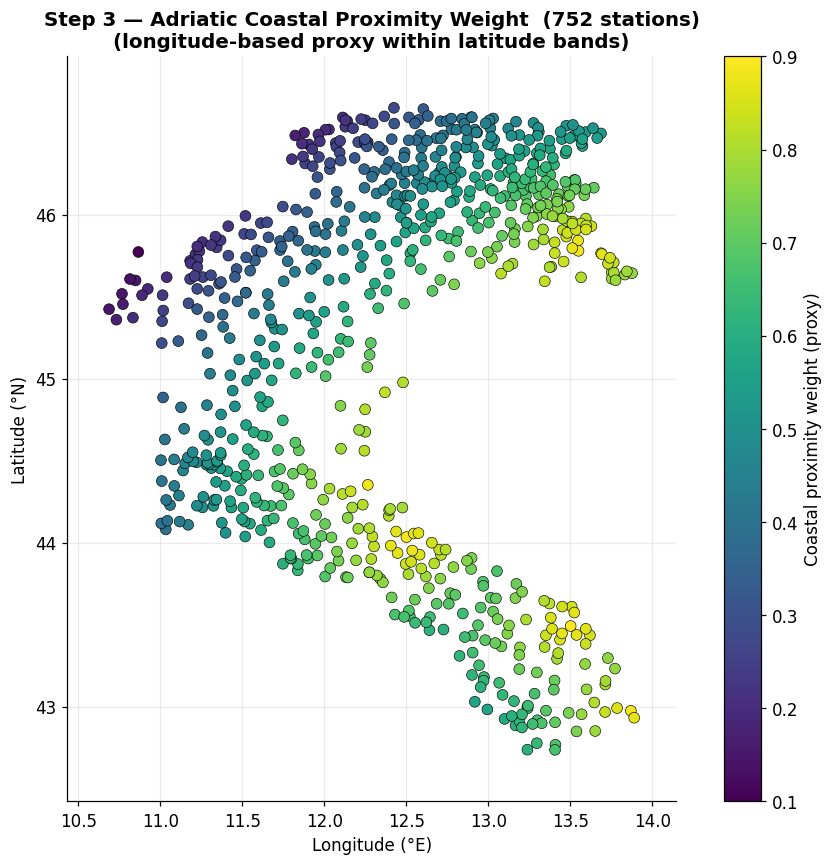

In [28]:
# ---- 3.3 Map: stations coloured by coastal proximity weight ----

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(dpc['lon'], dpc['lat'], c=dpc['coastal_weight'],
                 cmap='viridis', s=50, edgecolors='black', linewidths=0.4,
                 vmin=WEIGHT_MIN, vmax=WEIGHT_MAX, zorder=5)
plt.colorbar(sc, ax=ax, label='Coastal proximity weight (proxy)')

# Compute limits directly from the data, with a small margin
lon_margin = (dpc['lon'].max() - dpc['lon'].min()) * 0.08
lat_margin = (dpc['lat'].max() - dpc['lat'].min()) * 0.08
ax.set_xlim(dpc['lon'].min() - lon_margin, dpc['lon'].max() + lon_margin)
ax.set_ylim(dpc['lat'].min() - lat_margin, dpc['lat'].max() + lat_margin)

ax.set_aspect('equal')  # avoid horizontal stretching, keep geographic proportions correct
ax.set(xlabel='Longitude (°E)', ylabel='Latitude (°N)',
       title=f'Step 3 — Adriatic Coastal Proximity Weight  ({len(dpc)} stations)\n'
             f'(longitude-based proxy within latitude bands)')
plt.tight_layout()
plt.savefig('s3_coastal_weight_map.png', bbox_inches='tight')
plt.show()

In [29]:
# ---- 3.4 Save updated CSV with outlier flags + coastal weight ----

out_path = Path('DPC_stations_aggregated_dq.csv')
dpc.to_csv(out_path, index=False)
print(f'Saved -> {out_path}')
print(f'Shape : {dpc.shape}')

Saved -> DPC_stations_aggregated_dq.csv
Shape : (752, 34)


## 2.2 QC Summary

In [30]:
flag_cols = [f'{v}_range_flag' for v in available_vars if f'{v}_range_flag' in dpc.columns]
dpc['any_flag'] = dpc[flag_cols].any(axis=1) if flag_cols else False

print('='*55)
print('  STEP 2 QC SUMMARY')
print('='*55)
print(f'  Total stations        : {len(dpc)}')
print(f'  Stations with any flag: {dpc["any_flag"].sum()}')
print(f'  Clean stations        : {(~dpc["any_flag"]).sum()}')
print()
print('  Per-variable breakdown:')
for var in available_vars:
    col = f'{var}_range_flag'
    if col not in dpc.columns:
        continue
    n_total = dpc[f'{var}_value'].notna().sum()
    n_bad = dpc[col].sum()
    pct = 100 * n_bad / n_total if n_total > 0 else 0
    print(f'    {var:8s}: {n_bad:4d} flagged / {n_total:4d} total ({pct:.1f}%)')

dpc_clean = dpc[~dpc['any_flag']].copy()
dpc_flagged_rows = dpc[dpc['any_flag']].copy()
print(f'\n  dpc_clean  : {len(dpc_clean)} stations')
print(f'  dpc_flagged: {len(dpc_flagged_rows)} stations')

dpc_clean.to_csv('dpc_clean.csv', index=False)
dpc.to_csv('dpc_flagged.csv', index=False)
print('  Saved -> dpc_clean.csv  |  dpc_flagged.csv')

  STEP 2 QC SUMMARY
  Total stations        : 752
  Stations with any flag: 9
  Clean stations        : 743

  Per-variable breakdown:
    PREC    :    0 flagged /  715 total (0.0%)
    TARIA2M :    0 flagged /  617 total (0.0%)
    PRESS   :    9 flagged /   43 total (20.9%)
    VV      :    0 flagged /  142 total (0.0%)
    UMID2M  :    0 flagged /  149 total (0.0%)

  dpc_clean  : 743 stations
  dpc_flagged: 9 stations
  Saved -> dpc_clean.csv  |  dpc_flagged.csv


# Final Summary

In [31]:
print('='*60)
print('  DPC DATA QUALITY PIPELINE — SUMMARY')
print('='*60)
print(f'  STEP 1 — Inventory')
print(f'    Total stations       : {len(dpc)}')
print(f'    Canonical variables  : {len(available_vars)}')
print(f'    Populated (st,var) pairs: {len(inventory)}')
print()
print(f'  STEP 2 — QC')
print(f'    Range violations     : {dpc["any_flag"].sum()}')
print(f'    Clean stations       : {len(dpc_clean)}')
print()
print('  Skipped (not applicable to a single-snapshot, wide-format file):')
print('    - Flat-line detection  (needs a time series per station/variable)')
print('    - Gap detection        (needs a time series per station/variable)')
print('    - ERA5 cross-match     (requires external ERA5 grid files)')
print('    - Radar QC             (requires external GeoTIFF radar files)')
print()
print('  Saved files:')
for f in ['dpc_data_dictionary.csv', 'dpc_clean.csv', 'dpc_flagged.csv',
          's1_sensor_availability.png', 's1_station_map.png', 's2_range_check.png']:
    print(f'    {f}')
print('='*60)

  DPC DATA QUALITY PIPELINE — SUMMARY
  STEP 1 — Inventory
    Total stations       : 752
    Canonical variables  : 5
    Populated (st,var) pairs: 1666

  STEP 2 — QC
    Range violations     : 9
    Clean stations       : 743

  Skipped (not applicable to a single-snapshot, wide-format file):
    - Flat-line detection  (needs a time series per station/variable)
    - Gap detection        (needs a time series per station/variable)
    - ERA5 cross-match     (requires external ERA5 grid files)
    - Radar QC             (requires external GeoTIFF radar files)

  Saved files:
    dpc_data_dictionary.csv
    dpc_clean.csv
    dpc_flagged.csv
    s1_sensor_availability.png
    s1_station_map.png
    s2_range_check.png
